# Study Period Selection

This notebook selects a fixed calendar study period for the Gulf Stream
drifter trajectory prediction task.

The first step is to compare Gulf Stream drifter coverage across calendar
quarters and identify a sufficiently well-covered and relatively modern
quarter for subsequent modelling.

In [48]:
import numpy as np
in_region = np.load(
    "../data/processed/gulf_stream_in_region.npy",
    mmap_mode="r"
)

print("Shape:", in_region.shape)
print("dtype:", in_region.dtype)
print("Regional observations:", in_region.sum())

Shape: (197214787,)
dtype: bool
Regional observations: 8142739


In [49]:
import pandas as pd

df = pd.read_parquet(
    "../data/processed/gulf_stream_trajectories.parquet",
    columns=["trajectory_id", "time", "in_region"]
)

print("Shape:", df.shape)
print("Trajectories:", df["trajectory_id"].nunique())
print("Time range:", df["time"].min(), "to", df["time"].max())
print("Regional observations:", df["in_region"].sum())

Shape: (20216717, 3)
Trajectories: 1482
Time range: 1990-11-15 12:00:00 to 2022-10-31 00:00:00
Regional observations: 8142739


In [50]:
regional = df[df["in_region"]].copy()

# Assign each regional observation to a calendar quarter
regional["quarter"] = regional["time"].dt.to_period("Q")

quarterly_coverage = (
    regional.groupby("quarter")
    .agg(
        n_trajectories=("trajectory_id", "nunique"),
        n_regional_obs=("trajectory_id", "size")
    )
    .reset_index()
)

print(quarterly_coverage.shape)
print(quarterly_coverage.tail(20))

(115, 3)
    quarter  n_trajectories  n_regional_obs
95   2018Q1              78          113410
96   2018Q2              68          112706
97   2018Q3              77          118496
98   2018Q4              70          121264
99   2019Q1              77          104887
100  2019Q2              80          114844
101  2019Q3              79          124370
102  2019Q4              67          111177
103  2020Q1              55           80556
104  2020Q2              59           77560
105  2020Q3              95          123494
106  2020Q4             119          183508
107  2021Q1              97          123669
108  2021Q2              76          103458
109  2021Q3              79          131803
110  2021Q4              73          119312
111  2022Q1              64           95040
112  2022Q2              65           95136
113  2022Q3              71          116432
114  2022Q4              61           38838


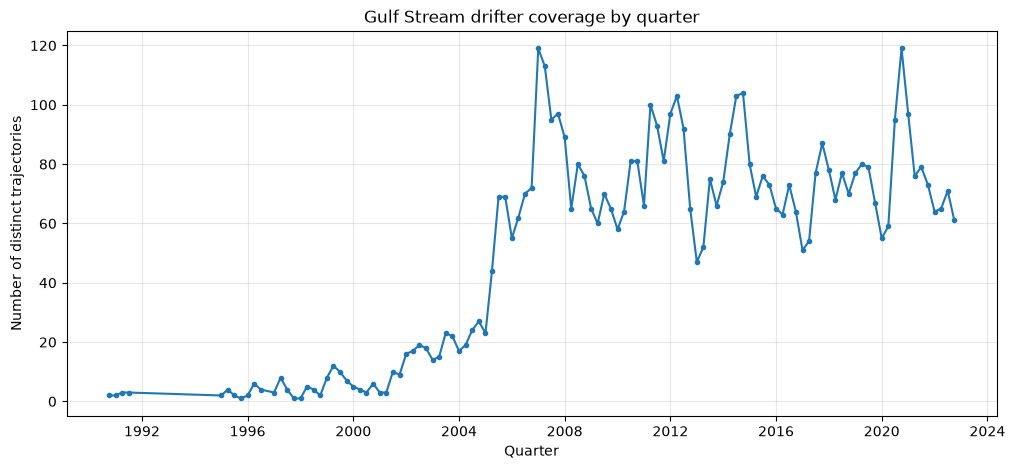

In [51]:
import matplotlib.pyplot as plt

quarterly_coverage["quarter_start"] = (
    quarterly_coverage["quarter"].dt.start_time
)

plt.figure(figsize=(12, 5))

plt.plot(
    quarterly_coverage["quarter_start"],
    quarterly_coverage["n_trajectories"],
    marker="o",
    markersize=3
)

plt.xlabel("Quarter")
plt.ylabel("Number of distinct trajectories")
plt.title("Gulf Stream drifter coverage by quarter")
plt.grid(alpha=0.3)

plt.show()

In [52]:
modern = quarterly_coverage[
    (quarterly_coverage["quarter"].dt.year >= 2006) &
    (quarterly_coverage["quarter"].dt.year <= 2022)
].copy()

modern["year"] = modern["quarter"].dt.year
modern["q"] = modern["quarter"].dt.quarter

quarter_comparison = modern.pivot(
    index="year",
    columns="q",
    values="n_trajectories"
)

quarter_comparison.columns = [
    "Q1_Jan-Mar",
    "Q2_Apr-Jun",
    "Q3_Jul-Sep",
    "Q4_Oct-Dec"
]

print(quarter_comparison)

      Q1_Jan-Mar  Q2_Apr-Jun  Q3_Jul-Sep  Q4_Oct-Dec
year                                                
2006          55          62          70          72
2007         119         113          95          97
2008          89          65          80          76
2009          65          60          70          65
2010          58          64          81          81
2011          66         100          93          81
2012          97         103          92          65
2013          47          52          75          66
2014          74          90         103         104
2015          80          69          76          73
2016          65          63          73          64
2017          51          54          77          87
2018          78          68          77          70
2019          77          80          79          67
2020          55          59          95         119
2021          97          76          79          73
2022          64          65          71      

In [53]:
quarter_summary = quarter_comparison.agg(
    ["mean", "median", "min", "max", "std"]
).T

quarter_summary["CV"] = (
    quarter_summary["std"] / quarter_summary["mean"]
)

print(quarter_summary.round(2))

             mean  median   min    max    std    CV
Q1_Jan-Mar  72.76    66.0  47.0  119.0  19.21  0.26
Q2_Apr-Jun  73.12    65.0  52.0  113.0  18.05  0.25
Q3_Jul-Sep  81.53    79.0  70.0  103.0  10.14  0.12
Q4_Oct-Dec  77.71    73.0  61.0  119.0  15.92  0.20


In [54]:
q3_regional = regional[
    (regional["time"].dt.year >= 2006) &
    (regional["time"].dt.year <= 2022) &
    (regional["time"].dt.quarter == 3)
].copy()

print(
    "Regional observations:",
    len(q3_regional)
)

print(
    "Unique trajectories:",
    q3_regional["trajectory_id"].nunique()
)

print(
    "Trajectory-year combinations:",
    q3_regional.assign(
        year=q3_regional["time"].dt.year
    )[["trajectory_id", "year"]]
    .drop_duplicates()
    .shape[0]
)

Regional observations: 2018052
Unique trajectories: 1000
Trajectory-year combinations: 1386


In [55]:
periods = {
    "2007_2010": (2007, 2010),
    "2011_2014": (2011, 2014),
    "2015_2018": (2015, 2018),
    "2019_2022": (2019, 2022)
}

regional_q3 = regional[
    (regional["time"].dt.year.between(2007, 2022)) &
    (regional["time"].dt.quarter == 3)
].copy()

regional_q3["year"] = regional_q3["time"].dt.year

for name, (start, end) in periods.items():
    temp = regional_q3[
        regional_q3["year"].between(start, end)
    ]

    trajectory_years = (
        temp[["trajectory_id", "year"]]
        .drop_duplicates()
    )

    print(
        name,
        "| trajectory-years:", len(trajectory_years),
        "| unique trajectories:", temp["trajectory_id"].nunique(),
        "| regional obs:", len(temp)
    )

2007_2010 | trajectory-years: 326 | unique trajectories: 251 | regional obs: 457418
2011_2014 | trajectory-years: 363 | unique trajectories: 320 | regional obs: 511532
2015_2018 | trajectory-years: 303 | unique trajectories: 231 | regional obs: 447213
2019_2022 | trajectory-years: 324 | unique trajectories: 240 | regional obs: 496099


In [56]:
# Add year and quarter to the mother dataframe
df["year"] = df["time"].dt.year
df["quarter"] = df["time"].dt.quarter

study_datasets = {}

for name, (start, end) in periods.items():

    # All observations occurring in Q3 of this 4-year period
    period_q3 = df[
        (df["year"].between(start, end)) &
        (df["quarter"] == 3)
    ]

    # Select trajectory-year combinations that entered
    # the Gulf Stream region during that year's Q3
    selected_pairs = (
        period_q3.loc[
            period_q3["in_region"],
            ["trajectory_id", "year"]
        ]
        .drop_duplicates()
    )

    # Keep ALL Q3 observations for those trajectory-year combinations
    study = period_q3.merge(
        selected_pairs,
        on=["trajectory_id", "year"],
        how="inner"
    )

    study_datasets[name] = study

    print(
        name,
        "| rows:", len(study),
        "| trajectory-years:",
        study[["trajectory_id", "year"]].drop_duplicates().shape[0],
        "| unique trajectories:",
        study["trajectory_id"].nunique(),
        "| regional obs:",
        study["in_region"].sum()
    )

2007_2010 | rows: 616023 | trajectory-years: 326 | unique trajectories: 251 | regional obs: 457418
2011_2014 | rows: 640974 | trajectory-years: 363 | unique trajectories: 320 | regional obs: 511532
2015_2018 | rows: 587026 | trajectory-years: 303 | unique trajectories: 231 | regional obs: 447213
2019_2022 | rows: 638638 | trajectory-years: 324 | unique trajectories: 240 | regional obs: 496099


In [57]:
mother = pd.read_parquet(
    "../data/processed/gulf_stream_trajectories.parquet"
)

print("Shape:", mother.shape)
print("Columns:", mother.columns.tolist())
print(mother.dtypes)

Shape: (20216717, 9)
Columns: ['trajectory_id', 'time', 'lon', 'lat', 've', 'vn', 'sst', 'drogue_status', 'in_region']
trajectory_id             int64
time             datetime64[ns]
lon                     float64
lat                     float64
ve                      float32
vn                      float32
sst                     float32
drogue_status              bool
in_region                  bool
dtype: object


In [58]:
mother["year"] = mother["time"].dt.year
mother["quarter"] = mother["time"].dt.quarter

for name, (start, end) in periods.items():

    # Q3 observations in this four-year period
    period_q3 = mother[
        (mother["year"].between(start, end)) &
        (mother["quarter"] == 3)
    ]

    # Select trajectory-year pairs that entered the Gulf Stream
    selected_pairs = (
        period_q3.loc[
            period_q3["in_region"],
            ["trajectory_id", "year"]
        ]
        .drop_duplicates()
    )

    # Keep all Q3 observations for selected trajectory-years
    study = period_q3.merge(
        selected_pairs,
        on=["trajectory_id", "year"],
        how="inner"
    )

    # Remove temporary calendar variables
    study = study.drop(columns=["year", "quarter"])

    output_path = (
        f"../data/processed/gulf_stream_q3_{name}.parquet"
    )

    study.to_parquet(
        output_path,
        index=False
    )

    print(
        name,
        "| shape:", study.shape,
        "| trajectories:", study["trajectory_id"].nunique(),
        "| regional obs:", study["in_region"].sum(),
        "| saved:", output_path
    )

2007_2010 | shape: (616023, 9) | trajectories: 251 | regional obs: 457418 | saved: ../data/processed/gulf_stream_q3_2007_2010.parquet
2011_2014 | shape: (640974, 9) | trajectories: 320 | regional obs: 511532 | saved: ../data/processed/gulf_stream_q3_2011_2014.parquet
2015_2018 | shape: (587026, 9) | trajectories: 231 | regional obs: 447213 | saved: ../data/processed/gulf_stream_q3_2015_2018.parquet
2019_2022 | shape: (638638, 9) | trajectories: 240 | regional obs: 496099 | saved: ../data/processed/gulf_stream_q3_2019_2022.parquet


In [59]:
test = pd.read_parquet(
    "../data/processed/gulf_stream_q3_2007_2010.parquet",
    columns=["trajectory_id", "time"]
)

test = test.sort_values(["trajectory_id", "time"])

test["time_gap_hours"] = (
    test.groupby("trajectory_id")["time"]
        .diff()
        .dt.total_seconds()
        / 3600
)

print(test["time_gap_hours"].value_counts().head(10))

print(
    "\nProportion exactly 1 hour:",
    (test["time_gap_hours"] == 1).mean()
)

print(
    "\nMaximum gap:",
    test["time_gap_hours"].max(),
    "hours"
)

time_gap_hours
1.0       615594
6553.0        38
6577.0        30
14.0          12
18.0           8
16.0           8
17.0           8
15.0           7
20.0           7
13.0           6
Name: count, dtype: int64

Proportion exactly 1 hour: 0.9993035974306154

Maximum gap: 24097.0 hours


In [60]:
import pandas as pd
import matplotlib.pyplot as plt

summary = []

for name in periods:
    temp = pd.read_parquet(
        f"../data/processed/gulf_stream_q3_{name}.parquet",
        columns=["in_region"]
    )

    inside = temp["in_region"].sum()
    outside = (~temp["in_region"]).sum()

    summary.append({
        "period": name,
        "inside_region": inside,
        "outside_region": outside
    })

region_summary = pd.DataFrame(summary)

region_summary

,period,inside_region,outside_region
0,2007_2010,457418,158605
1,2011_2014,511532,129442
2,2015_2018,447213,139813
3,2019_2022,496099,142539


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

outside_list = []

for name in periods:
    temp = pd.read_parquet(
        f"../data/processed/gulf_stream_q3_{name}.parquet",
        columns=["lon", "lat", "in_region"]
    )

    temp = temp[~temp["in_region"]].copy()
    temp["period"] = name
    outside_list.append(temp)

outside = pd.concat(outside_list, ignore_index=True)

print("Outside observations:", len(outside))
print("\nLongitude range:")
print(outside["lon"].agg(["min", "max"]))

print("\nLatitude range:")
print(outside["lat"].agg(["min", "max"]))

Outside observations: 570399

Longitude range:
min   -90.638943
max   -28.718960
Name: lon, dtype: float64

Latitude range:
min    13.194880
max    58.588088
Name: lat, dtype: float64


In [62]:
from matplotlib.patches import Rectangle

outside[["lon", "lat"]].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

,lon,lat
0.01,-85.995675,19.805021
0.05,-74.220449,21.725128
0.25,-59.817182,24.194625
0.50,-49.251751,28.258200
0.75,-46.552836,36.752729
0.95,-41.124440,44.448677
0.99,-36.248750,49.625117


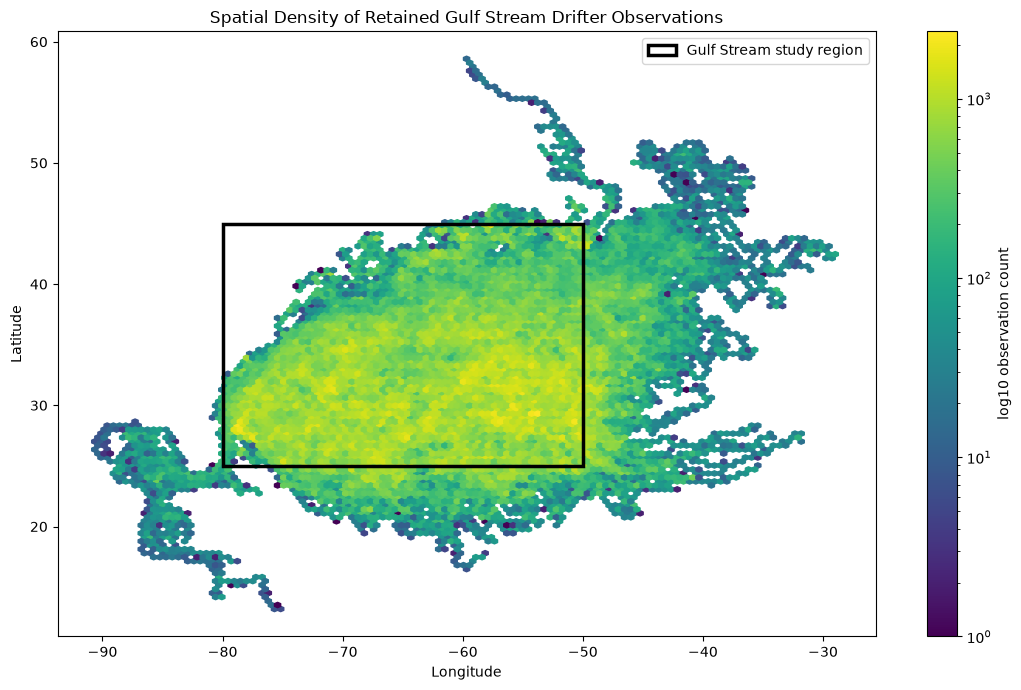

In [63]:
# Combine all four study datasets
all_obs = []

for name in periods:
    temp = pd.read_parquet(
        f"../data/processed/gulf_stream_q3_{name}.parquet",
        columns=["lon", "lat", "in_region"]
    )
    all_obs.append(temp)

all_obs = pd.concat(all_obs, ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 7))

# Density of all retained observations
hb = ax.hexbin(
    all_obs["lon"],
    all_obs["lat"],
    gridsize=120,
    mincnt=1,
    bins="log"
)

# Gulf Stream region
region_box = Rectangle(
    (-80, 25),
    30,
    20,
    fill=False,
    linewidth=2.5,
    label="Gulf Stream study region"
)

ax.add_patch(region_box)

cbar = plt.colorbar(hb, ax=ax)
cbar.set_label("log10 observation count")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Spatial Density of Retained Gulf Stream Drifter Observations"
)

ax.legend()
plt.tight_layout()
plt.show()